## Regression and Visualization

This notebooks examines and visualizes the splittability probabilities calculated for dual graphs at the county, tract, and block group levels. 

In [1]:
#import packages 
import networkx as nx
import json
from networkx.readwrite import json_graph
import matplotlib.pyplot as plt
import numpy as np
import random
import networkx as nx
from collections import deque
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# geographies considered
geogs = ['cnty', 't','bg']

# Dictionaries helpful for displaying figure titles, etc. 
gdict = {'cnty': "County", 
         't': "Tract",
         'bg': "Block Group",
         'b': "Block"}
gdicts = {'cnty': "Counties", 
         't': "Tracts",
         'bg': "Block Groups",
         'b': "Blocks"}

# Linear regression function calculating y-values given x, a, and b
def linear_regression(log_x, a, b): 
    return (a*log_x) + b 

# Colors used in plots; consistent across plots
color = {'cnty':'#4daf4a', 
         't':'#377eb8',
         'bg':'#e41a1c'
}

In [2]:
# Read in data
data = {}
for g in geogs: 
    data[g] = pd.read_csv(g + "_results.csv")
    print(len(data[g]))


146
66
47


# Plot each data set individually

Linear Regression: Counties, k = 2
Original formula: ln(y) = -1.0991 * ln(x) + 1.0702
MSE = 0.0580, R^2 = 0.9337
Equation for Non-transformed Data: y = 2.9160 * x^-1.0991

Linear Regression: Tracts, k = 2
Original formula: ln(y) = -0.9887 * ln(x) + -0.5091
MSE = 0.2065, R^2 = 0.8289
Equation for Non-transformed Data: y = 0.6010 * x^-0.9887

Linear Regression: Block Groups, k = 2
Original formula: ln(y) = -0.9669 * ln(x) + -0.9440
MSE = 0.2027, R^2 = 0.8260
Equation for Non-transformed Data: y = 0.3891 * x^-0.9669

Linear Regression: Counties, k = 3
Original formula: ln(y) = -2.2818 * ln(x) + 3.3940
MSE = 0.0775, R^2 = 0.9785
Equation for Non-transformed Data: y = 29.7859 * x^-2.2818

Linear Regression: Tracts, k = 3
Original formula: ln(y) = -2.1363 * ln(x) + 0.9416
MSE = 0.7121, R^2 = 0.6706
Equation for Non-transformed Data: y = 2.5640 * x^-2.1363

Linear Regression: Counties, k = 4
Original formula: ln(y) = -3.2739 * ln(x) + 5.3569
MSE = 0.1077, R^2 = 0.9829
Equation for Non-transfo

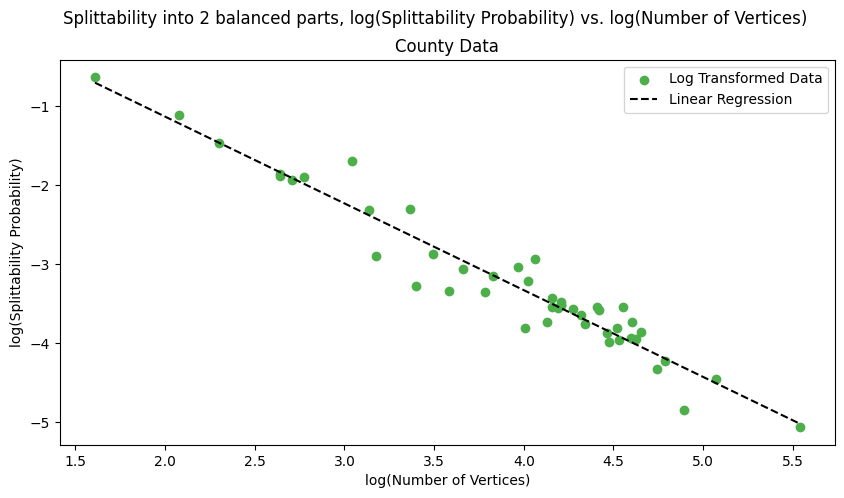

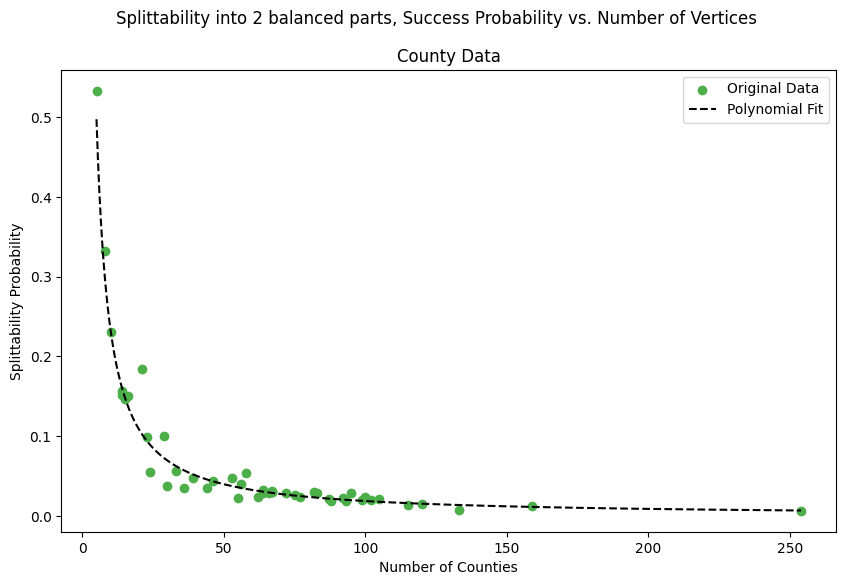

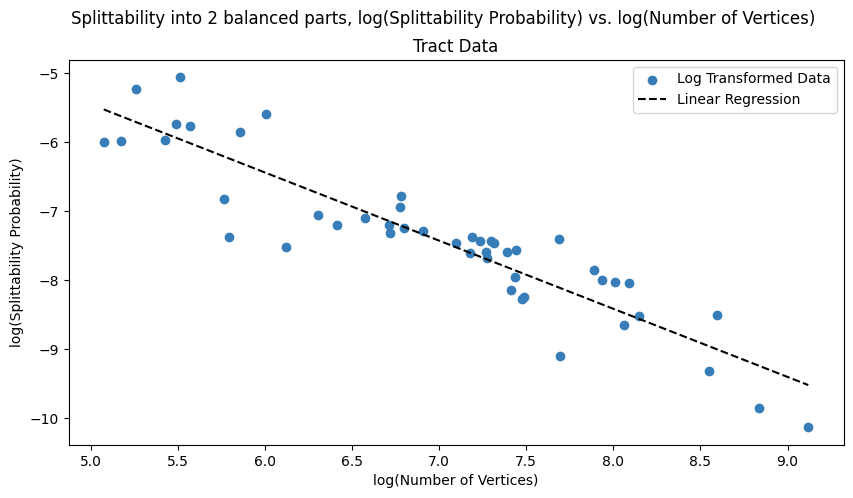

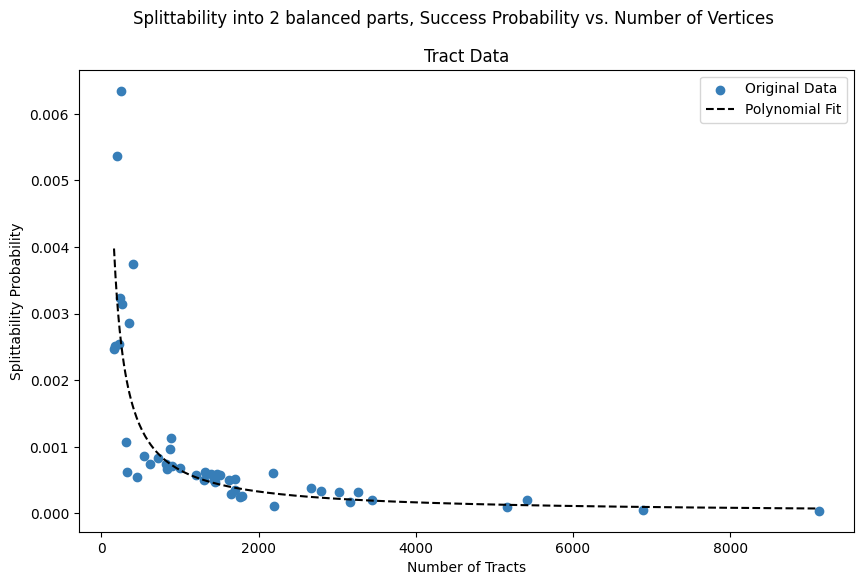

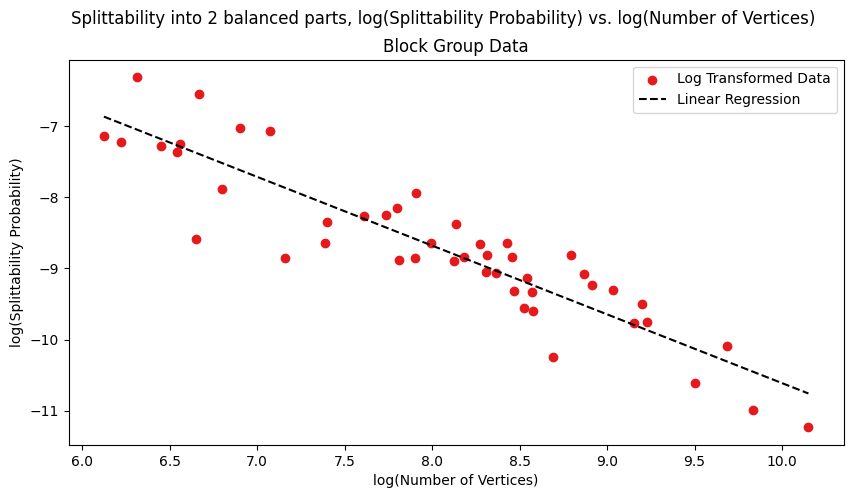

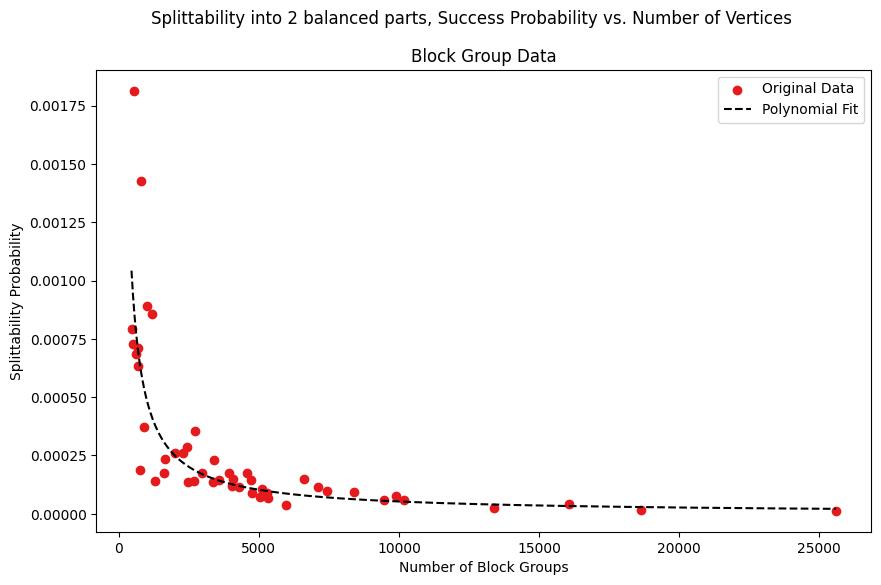

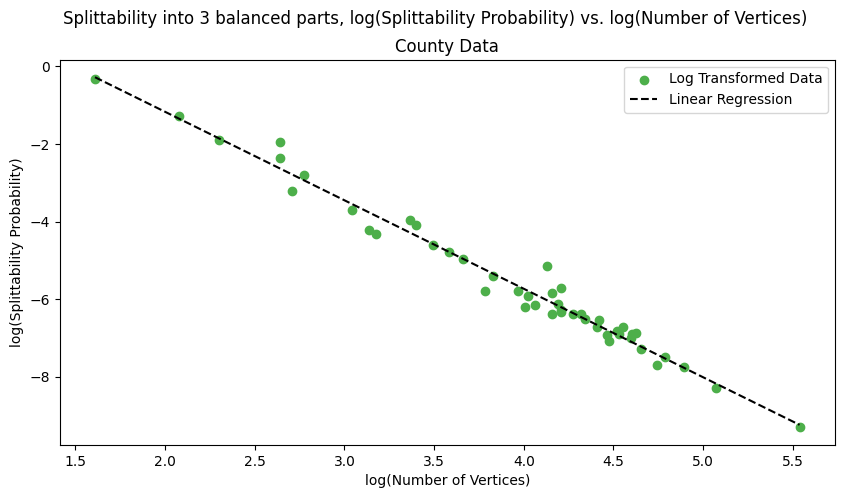

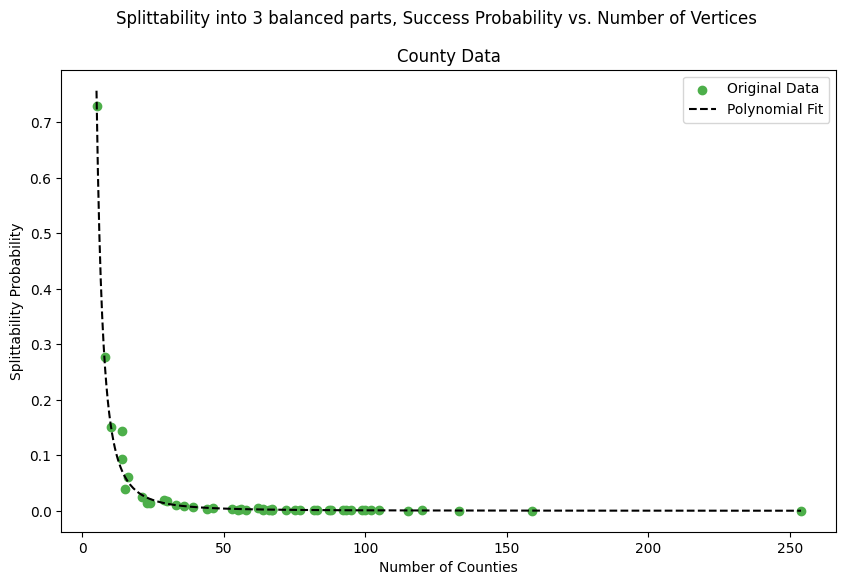

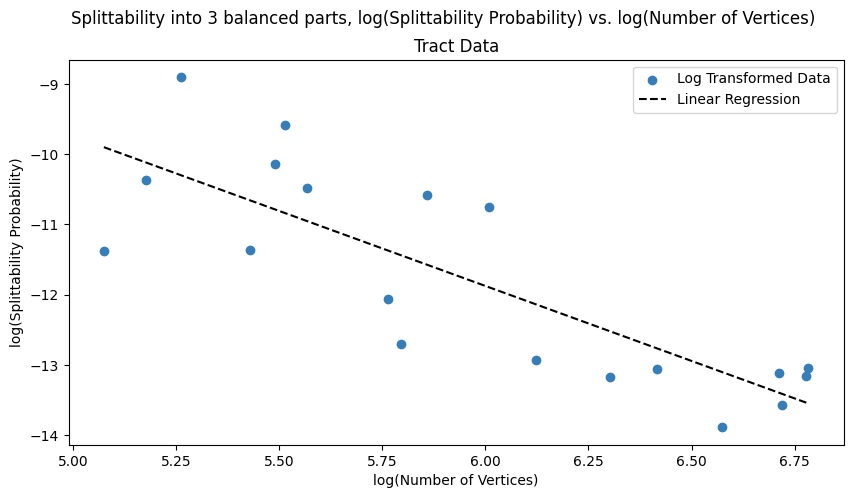

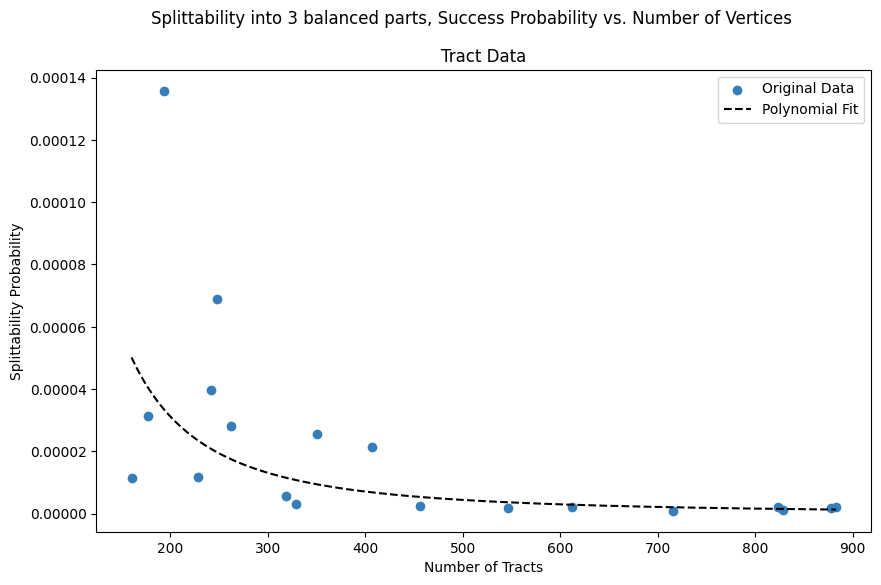

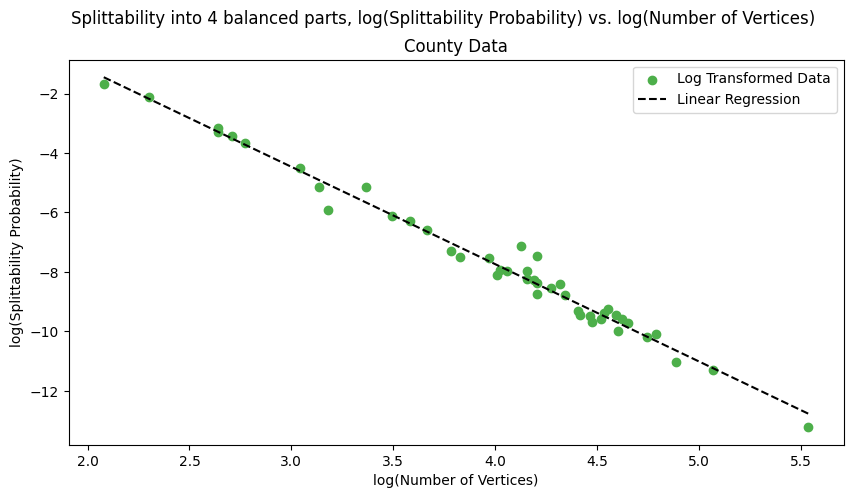

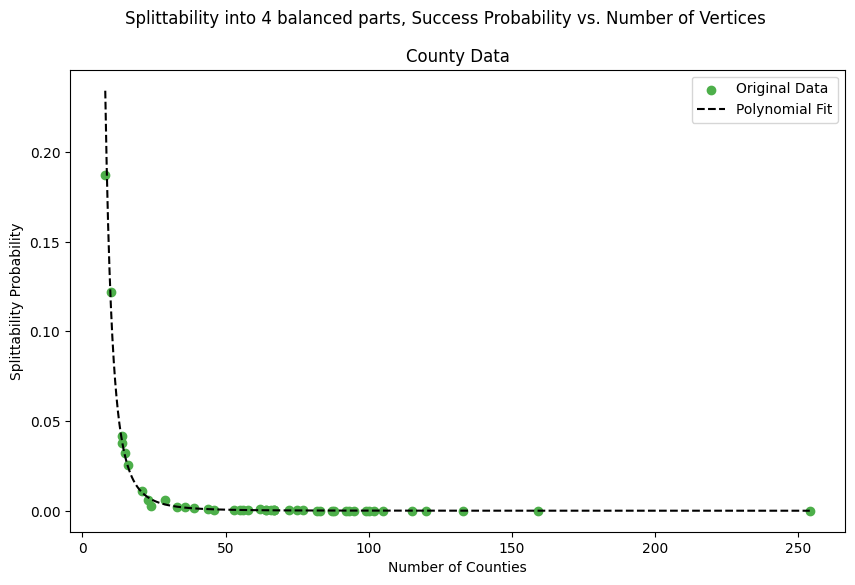

In [3]:
# Which pairs of data we have
pairs = [(2, 'cnty'), (2,'t'), (2,'bg'), (3,'cnty'), (3,'t'), (4,'cnty')]
# Dictionaries that will store our data, regressions, and results along the way
# keys will by k + g, where k is number of parts and g is geography
logx = {}
logy = {}
x = {}
y = {}
params_linear = {}
a_linear = {}
b_linear = {}
c = {}
pred_linear = {}
mse_linear = {}
r2_linear = {}
x_vals_log = {}
y_vals_linear = {}
x_vals = {}
y_vals = {}

for (k,g) in pairs:
    # Get data
    d = data[g]
    # Only keep data for correct number of partitions
    dk = d[d["Partitions"] == k]

    # For county, exclude hawaii, which is disconnected, and deleware, which has only 3 counties in a path (and thus only one ST)
    if g == "cnty":
        dk = dk[~dk["State"].isin(["hi", "de"])]
    # All spanning trees of Rhode Island's counties are 4-splittable, so exclude from results
    # Note Alaska is also excluded, as no spanning trees of Alaska's counties are 4-splittable
    if g == 'cnty' and k == 4:
        dk = dk[~dk["State"].isin(["ri"])]

    k = str(k) # for easier concatentation and use as a key

    #creating new log transformed variables 
    x[g+k] = np.array(dk["Num Vertices"])
    logx[g+k] = np.log(x[g+k])
    y[g+k] = np.array(dk["Success Rate"])
    logy[g+k]= np.log(y[g+k])
    
    # Do linear regression
    params_linear[g+k], _ = curve_fit(linear_regression, logx[g+k], logy[g+k], maxfev=10000)
    a_linear[g+k], b_linear[g+k] = params_linear[g+k]

    # Make predictions using the results of this regression
    pred_linear[g+k] = linear_regression(logx[g+k], a_linear[g+k], b_linear[g+k])

    # Calculate mean squared error and R^2 value
    mse_linear[g+k] = mean_squared_error(logy[g+k], pred_linear[g+k])
    r2_linear[g+k] = r2_score(logy[g+k], pred_linear[g+k])

    # Print output of linear regression
    print(f"Linear Regression: {gdicts[g]}, k = {k}")
    print(f"Original formula: ln(y) = {a_linear[g+k]:.4f} * ln(x) + {b_linear[g+k]:.4f}")
    print(f"MSE = {mse_linear[g+k]:.4f}, R^2 = {r2_linear[g+k]:.4f}")

    # Transform data back to original scale, print equation
    c[g+k] = np.exp(b_linear[g+k])
    print(f"Equation for Non-transformed Data: y = {c[g+k]:.4f} * x^{a_linear[g+k]:.4f}\n")
    
    # Plot transformed data
    x_vals_log[g+k] = np.linspace(min(logx[g+k]), max(logx[g+k]), 500) # x-values for regression line
    y_vals_linear[g+k] = linear_regression(x_vals_log[g+k], a_linear[g+k], b_linear[g+k]) # y-values for regression line
    
    plt.figure(figsize=(10, 5))
    plt.scatter(logx[g+k], logy[g+k], color=color[g], label="Log Transformed Data")
    plt.plot(x_vals_log[g+k], y_vals_linear[g+k], "k--", label="Linear Regression")
    plt.xlabel(f"log(Number of Vertices)")
    plt.ylabel("log(Splittability Probability)")
    plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
    plt.title(f"{gdict[g]} Data")
    plt.legend()
    plt.savefig(f"fig/{g}_{k}_log_v_log.png")

    # Plot original data
    x_vals[g+k] = np.linspace(min(x[g+k]), max(x[g+k]), 500) # x values for curve
    y_vals[g+k] = c[g+k] * (x_vals[g+k] ** a_linear[g+k]) # y values for curve
    
    plt.figure(figsize=(10, 6))
    plt.scatter(x[g+k], y[g+k], color=color[g], label="Original Data")
    plt.plot(x_vals[g+k], y_vals[g+k], "k--", label="Polynomial Fit")
    plt.xlabel(f"Number of {gdicts[g]}")
    plt.ylabel("Splittability Probability")
    plt.suptitle(f"Splittability into {k} balanced parts, Success Probability vs. Number of Vertices")
    plt.title(f"{gdict[g]} Data")
    plt.legend()
    plt.savefig(f"fig/{g}_{k}_orig.png")


# Custom plots combining multiple data sets together

### k = 2, all 3 geographies

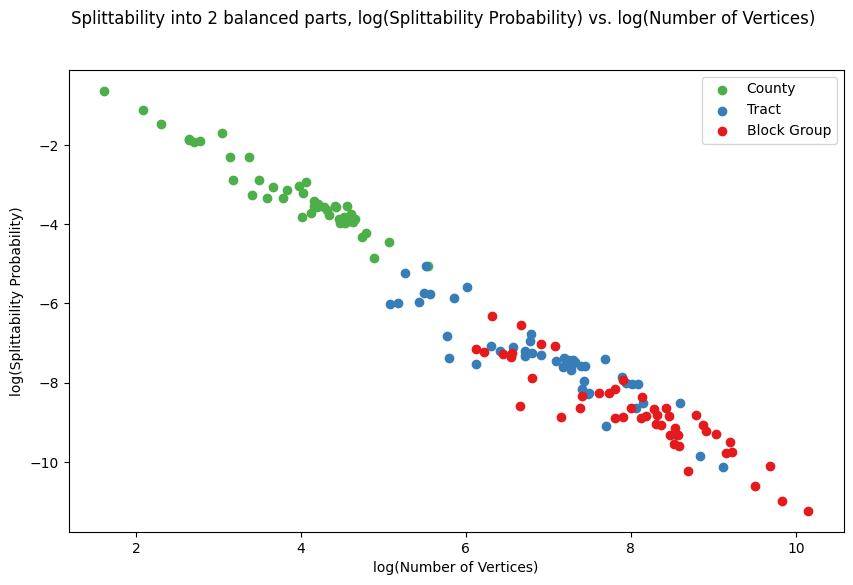

In [5]:
## Plot all three on the same plot
k = "2"
    
plt.figure(figsize=(10, 6))

plt.scatter(logx['cnty2'], logy['cnty2'], color='#4daf4a', label="County")
plt.scatter(logx['t2'], logy['t2'], color='#377eb8', label="Tract")
plt.scatter(logx['bg2'], logy['bg2'], color='#e41a1c', label="Block Group")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/all_{k}_log_v_log_nolines.png")


In [6]:
## Linear regression for all three at once
k = 2
cnty = data["cnty"][data["cnty"]["Partitions"] == k]
cnty = cnty[~cnty["State"].isin(["hi", "de"])]
t = data["t"][data["t"]["Partitions"] == k]

all = pd.concat([cnty, t, data["bg"]], axis = 0)
key = "all2" # So can reuse code from above, and store in same dictionaries

#creating new log variables 
x[key] = np.array(all["Num Vertices"])
logx[key]= np.log(x[key])
y[key] = np.array(all["Success Rate"])
logy[key]= np.log(y[key])
        
# Do linear regression
params_linear[key], _ = curve_fit(linear_regression, logx[key], logy[key], maxfev=10000)
a_linear[key], b_linear[key] = params_linear[key]
pred_linear[key] = linear_regression(logx[key], a_linear[key], b_linear[key])
mse_linear[key] = mean_squared_error(logy[key], pred_linear[key])
r2_linear[key] = r2_score(logy[key], pred_linear[key])

print(f"Linear Regression: All 3 Geographies, k = 2")
print(f"Original formula: ln(y) = {a_linear[key]:.4f} * ln(x) + {b_linear[key]:.4f}")
print(f"MSE = {mse_linear[key]:.4f}, R^2 = {r2_linear[key]:.4f}")

# Transform back to original scale
c[key] = np.exp(b_linear[key])

print(f"Equation for Non-transformed Data: p = {c[key]:.4f} n^{a_linear[key]:.4f}\n")

Linear Regression: All 3 Geographies, k = 2
Original formula: ln(y) = -1.2622 * ln(x) + 1.5123
MSE = 0.2368, R^2 = 0.9637
Equation for Non-transformed Data: p = 4.5370 n^-1.2622



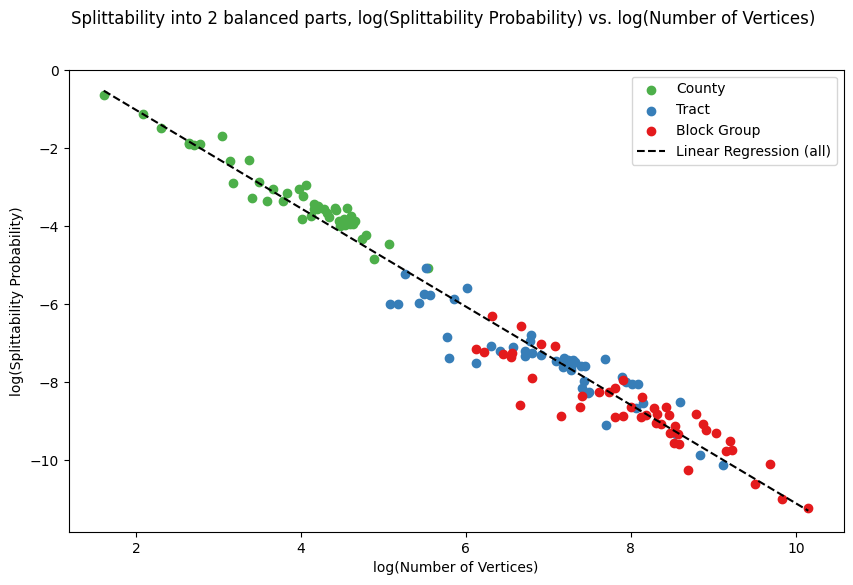

In [7]:
## Plot overall regression on top of data
x_vals_log["all2"] = np.linspace(min(logx["all2"]), max(logx["all2"]), 500)
y_vals_linear["all2"] = linear_regression(x_vals_log["all2"], a_linear["all2"], b_linear["all2"])

plt.figure(figsize=(10, 6)) 
plt.scatter(logx['cnty2'], logy['cnty2'], color='#4daf4a', label="County")
plt.scatter(logx['t2'], logy['t2'], color='#377eb8', label="Tract")
plt.scatter(logx['bg2'], logy['bg2'], color='#e41a1c', label="Block Group")
plt.plot(x_vals_log["all2"], y_vals_linear["all2"], "k--", label="Linear Regression (all)")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/all_{k}_log_v_log.png")

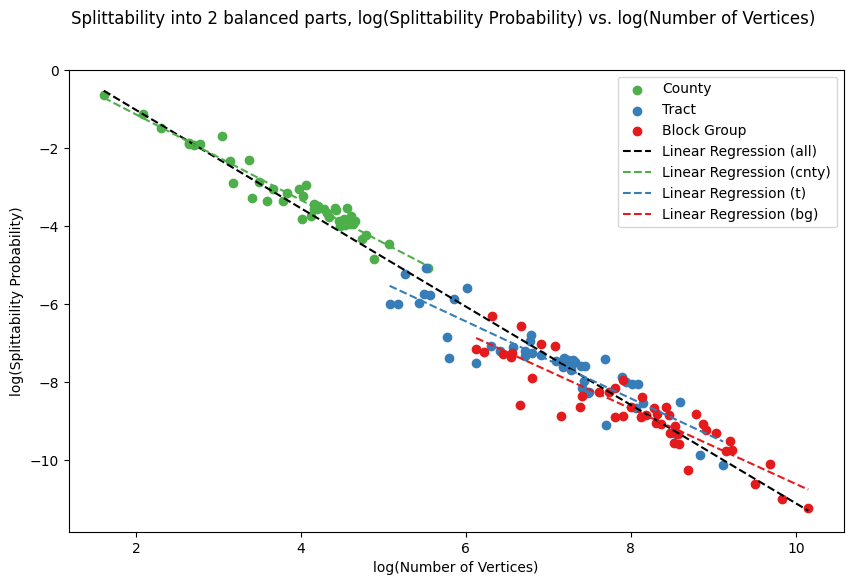

In [12]:
## Plot all regressions on top of data
   
plt.figure(figsize=(10, 6)) 
plt.scatter(logx['cnty2'], logy['cnty2'], color='#4daf4a', label="County")
plt.scatter(logx['t2'], logy['t2'], color='#377eb8', label="Tract")
plt.scatter(logx['bg2'], logy['bg2'], color='#e41a1c', label="Block Group")
plt.plot(x_vals_log["all2"], y_vals_linear["all2"], "k--", label="Linear Regression (all)")
plt.plot(x_vals_log["cnty2"], y_vals_linear["cnty2"], "--", color = '#4daf4a', label="Linear Regression (cnty)")
plt.plot(x_vals_log["t2"], y_vals_linear["t2"], "--", color='#377eb8', label="Linear Regression (t)")
plt.plot(x_vals_log["bg2"], y_vals_linear["bg2"], "--", color='#e41a1c', label="Linear Regression (bg)")


plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/all_{k}_log_v_log_alllines.png")

## k = 2, t and bg

In [13]:
tbg = pd.concat([t, data["bg"]], axis = 0)
g = "tbg2"

#creating new log variables 
x[g] = np.array(tbg["Num Vertices"])
logx[g]= np.log(x[g])
y[g] = np.array(tbg["Success Rate"])
logy[g]= np.log(y[g])
        
# Do linear regression
params_linear[g], _ = curve_fit(linear_regression, logx[g], logy[g], maxfev=10000)
a_linear[g], b_linear[g] = params_linear[g]

pred_linear[g] = linear_regression(logx[g], a_linear[g], b_linear[g])

mse_linear[g] = mean_squared_error(logy[g], pred_linear[g])
r2_linear[g] = r2_score(logy[g], pred_linear[g])

print(f"Linear Regression:")
print(f"Original formula: ln(y) = {a_linear[g]:.4f} * ln(x) + {b_linear[g]:.4f}")
print(f"MSE = {mse_linear[g]:.4f}, R^2 = {r2_linear[g]:.4f}")

# Transform back to original scale
c[g] = np.exp(b_linear[g])

print(f"Equation for Non-transformed Data: p = {c[g]:.4f} n^{a_linear[g]:.4f}\n")

Linear Regression:
Original formula: ln(y) = -1.0324 * ln(x) + -0.3113
MSE = 0.2192, R^2 = 0.8634
Equation for Non-transformed Data: p = 0.7325 n^-1.0324



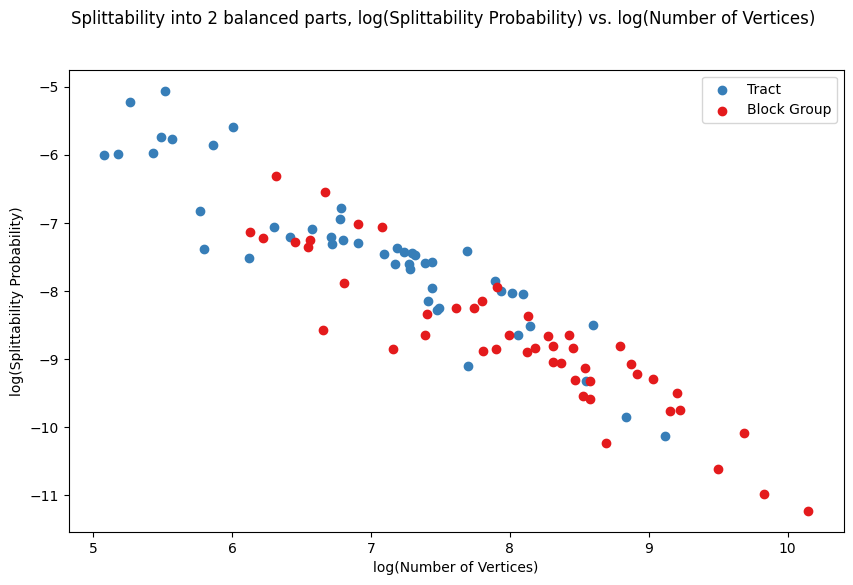

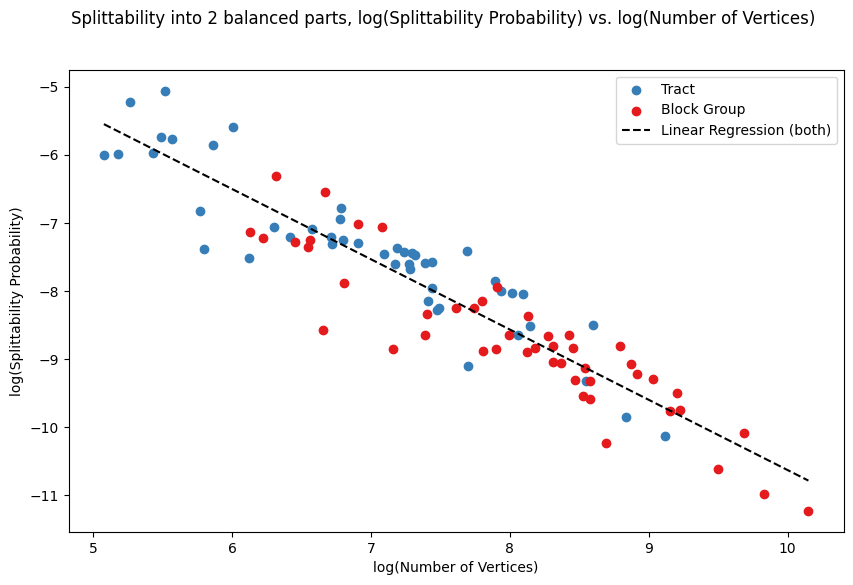

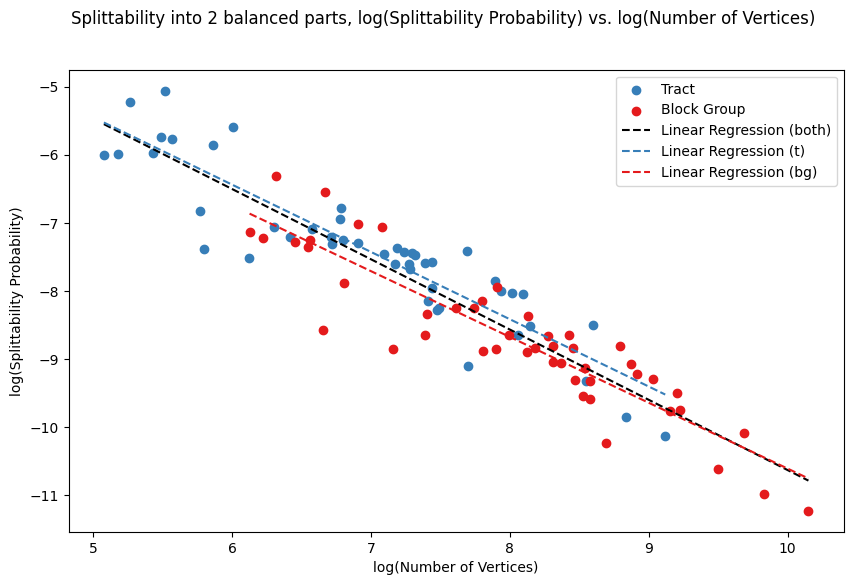

In [15]:
g = "tbg2"
k = 2

x_vals_log[g] = np.linspace(min(logx[g]), max(logx[g]), 500)
y_vals_linear[g] = linear_regression(x_vals_log[g], a_linear[g], b_linear[g])



# PLOT BOTH, NO LINES
plt.figure(figsize=(10, 6)) 
plt.scatter(logx['t2'], logy['t2'], color='#377eb8', label="Tract")
plt.scatter(logx['bg2'], logy['bg2'], color='#e41a1c', label="Block Group")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/tbg_{k}_log_v_log_nolines.png")


plt.figure(figsize=(10, 6)) 
plt.scatter(logx['t2'], logy['t2'], color='#377eb8', label="Tract")
plt.scatter(logx['bg2'], logy['bg2'], color='#e41a1c', label="Block Group")
plt.plot(x_vals_log[g], y_vals_linear[g], "k--", label="Linear Regression (both)")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/tbg_{k}_log_v_log.png")


plt.figure(figsize=(10, 6)) 
plt.scatter(logx['t2'], logy['t2'], color='#377eb8', label="Tract")
plt.scatter(logx['bg2'], logy['bg2'], color='#e41a1c', label="Block Group")
plt.plot(x_vals_log[g], y_vals_linear[g], "k--", label="Linear Regression (both)")
plt.plot(x_vals_log["t2"], y_vals_linear["t2"], "--",color='#377eb8', label="Linear Regression (t)")
plt.plot(x_vals_log["bg2"], y_vals_linear["bg2"], "--",color='#e41a1c', label="Linear Regression (bg)")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/tbg_{k}_log_v_log_alllines.png")

## k = 3, cnty and t

Linear Regression:
Original formula: ln(y) = -2.7370 * ln(x) + 4.9912
MSE = 0.4808, R^2 = 0.9570
Equation for Non-transformed Data: p = 147.1171 n^-2.7370



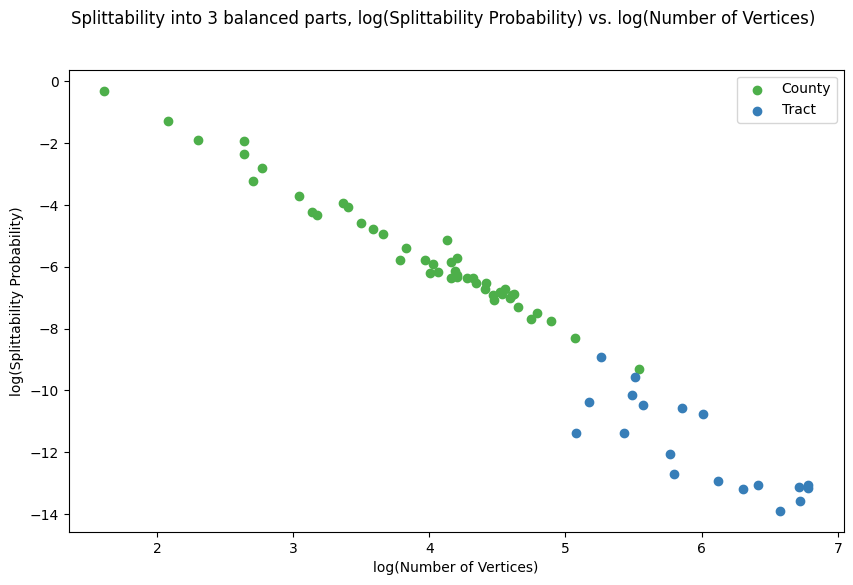

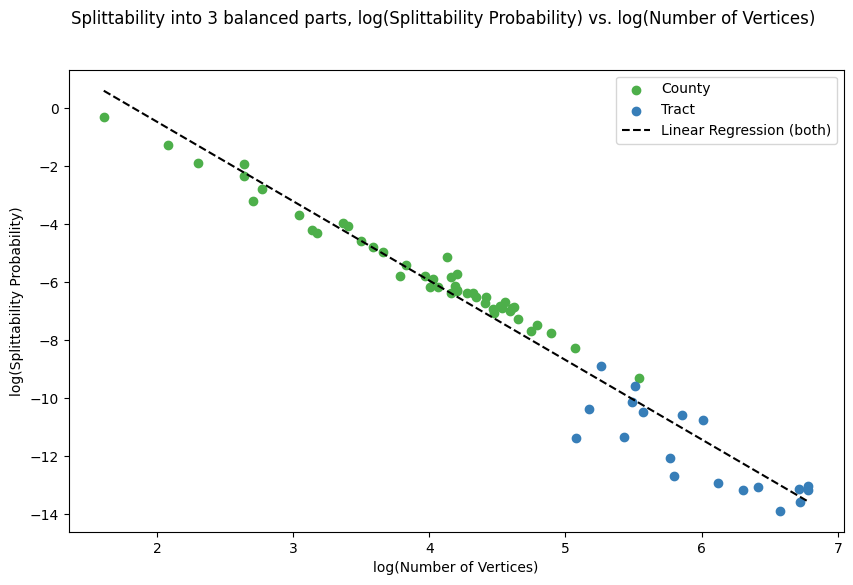

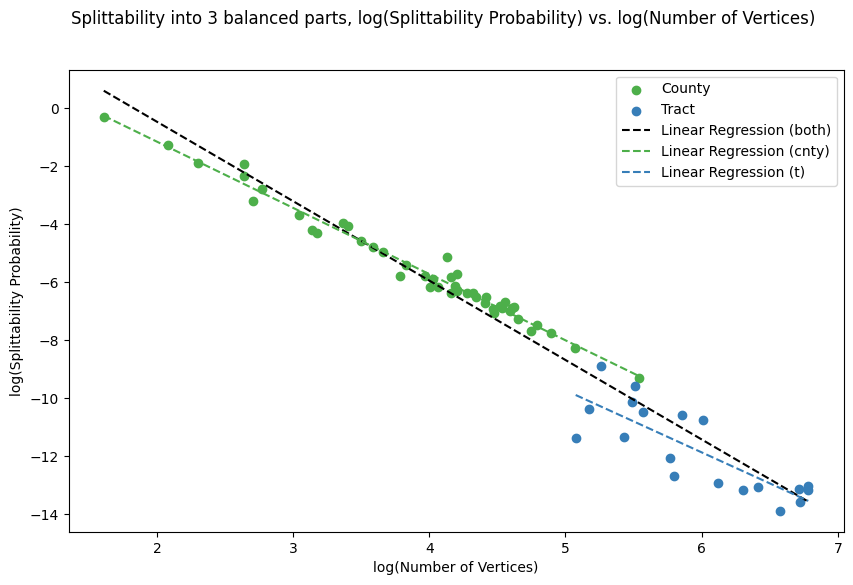

In [18]:
k = 3
cnty = data["cnty"][data["cnty"]["Partitions"] == k]
cnty = cnty[~cnty["State"].isin(["hi", "de"])]
t = data["t"][data["t"]["Partitions"] == k]

ct = pd.concat([cnty, t], axis = 0)
g = "ct3"

#creating new log variables 
x[g] = np.array(ct["Num Vertices"])
logx[g]= np.log(x[g])
y[g] = np.array(ct["Success Rate"])
logy[g]= np.log(y[g])
        
# DO LINEAR REGRESSION
params_linear[g], _ = curve_fit(linear_regression, logx[g], logy[g], maxfev=10000)
a_linear[g], b_linear[g] = params_linear[g]

pred_linear[g] = linear_regression(logx[g], a_linear[g], b_linear[g])

mse_linear[g] = mean_squared_error(logy[g], pred_linear[g])
r2_linear[g] = r2_score(logy[g], pred_linear[g])

print(f"Linear Regression:")
print(f"Original formula: ln(y) = {a_linear[g]:.4f} * ln(x) + {b_linear[g]:.4f}")
print(f"MSE = {mse_linear[g]:.4f}, R^2 = {r2_linear[g]:.4f}")

# Transform back to original scale
c[g] = np.exp(b_linear[g])

print(f"Equation for Non-transformed Data: p = {c[g]:.4f} n^{a_linear[g]:.4f}\n")


# PLOT BOTH, NO LINES

plt.figure(figsize=(10, 6)) 
plt.scatter(logx['cnty3'], logy['cnty3'], color='#4daf4a', label="County")
plt.scatter(logx['t3'], logy['t3'], color='#377eb8', label="Tract")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/all_{k}_log_v_log_nolines.png")


# PLOT BOTH WITH OVERALL REGRESSION LINE

x_vals_log[g] = np.linspace(min(logx[g]), max(logx[g]), 500)
y_vals_linear[g] = linear_regression(x_vals_log[g], a_linear[g], b_linear[g])

plt.figure(figsize=(10, 6)) 
plt.scatter(logx['cnty3'], logy['cnty3'], color='#4daf4a', label="County")
plt.scatter(logx['t3'], logy['t3'], color='#377eb8', label="Tract")
plt.plot(x_vals_log[g], y_vals_linear[g], "k--", label="Linear Regression (both)")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/all_{k}_log_v_log.png")

# PLOT BOTH WITH ALL REGRESSION LINES

plt.figure(figsize=(10, 6)) 
plt.scatter(logx['cnty3'], logy['cnty3'], color='#4daf4a', label="County")
plt.scatter(logx['t3'], logy['t3'], color='#377eb8', label="Tract")
plt.plot(x_vals_log[g], y_vals_linear[g], "k--", label="Linear Regression (both)")
plt.plot(x_vals_log["cnty3"], y_vals_linear["cnty3"], "--", color='#4daf4a',label="Linear Regression (cnty)")
plt.plot(x_vals_log["t3"], y_vals_linear["t3"], "--", color='#377eb8', label="Linear Regression (t)")

plt.xlabel(f"log(Number of Vertices)")
plt.ylabel("log(Splittability Probability)")
plt.suptitle(f"Splittability into {k} balanced parts, log(Splittability Probability) vs. log(Number of Vertices)")
plt.legend()
plt.savefig(f"fig/all_{k}_log_v_log_alllines.png")
